## 데이터 분포

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# 한글폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

In [2]:
# 데이터 로드
mpg = sns.load_dataset('mpg')
print(f'전체데이터: {len(mpg)}')
mpg.describe()

전체데이터: 398


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


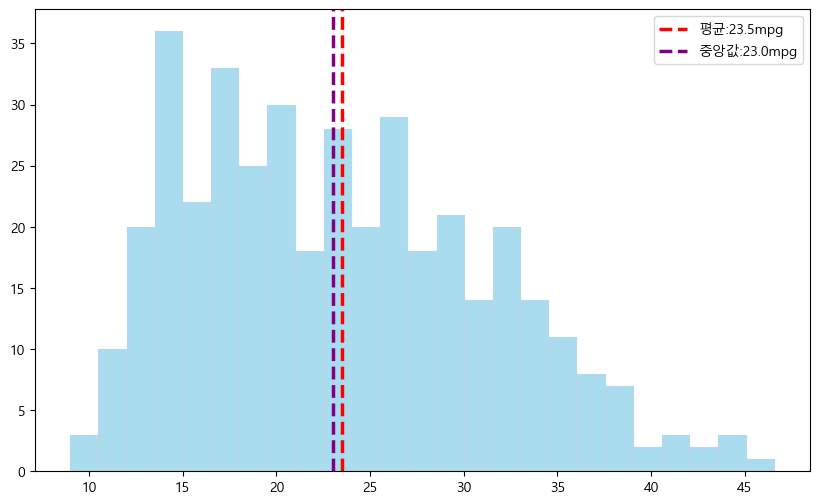

In [11]:
# 연비는 정규분포를 따를까?
# 히스토그램
fig, ax = plt.subplots(figsize=(10,6))
n, bins, patches = ax.hist(mpg['mpg'], bins=25, edgecolor = 'pink', color = 'skyblue', alpha = 0.7,
        linewidth=0.2)  # bins 구간 나구기

n, bins, patches

# 평균선 추가
mean_mpg = mpg['mpg'].mean()
ax.axvline(mean_mpg, color ='red', linestyle = '--', linewidth = 2.5, label = f'평균:{mean_mpg:.1f}mpg')

# 중앙선
mean_mpg = mpg['mpg'].median()
ax.axvline(mean_mpg, color ='purple', linestyle = '--', linewidth = 2.5, label = f'중앙값:{mean_mpg:.1f}mpg')

ax.legend()

# 정규분포는 대칭성
# 평균 = 중앙값 = 최빈값
# 좌우가 대칭 종모양

# 평균 > 중앙값 -> 우측 꼬리 존재(고연비 차량 존재 -> 정규분포 아님)
# 10-20에 집중 -> 저연비 차량 비중이 높다
# 평균 < 중앙값 -> 좌측 꼬리 존재


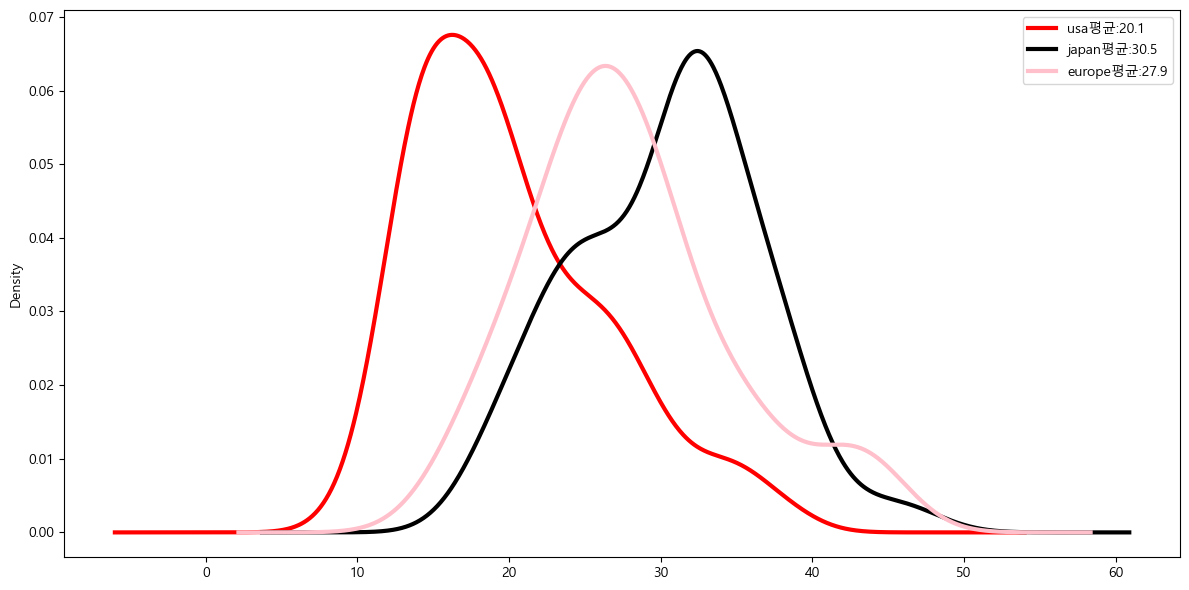

In [ ]:
# 밀도 (부드러운 분포 곡선)
# 국가별 연비분포
colors = {
    'usa': 'red',
    'japan': 'black',
    'europe': 'pink'
}
fig, ax = plt.subplots(figsize = (12,6))
for origin, color in colors.items():
    data = mpg['origin'] == origin
    data = mpg[data]['mpg']
    data.plot.kde(ax=ax, color=color, linewidth=3, label=f'{origin}평균:{data.mean():.1f}')

ax.legend()
plt.tight_layout()
plt.show()


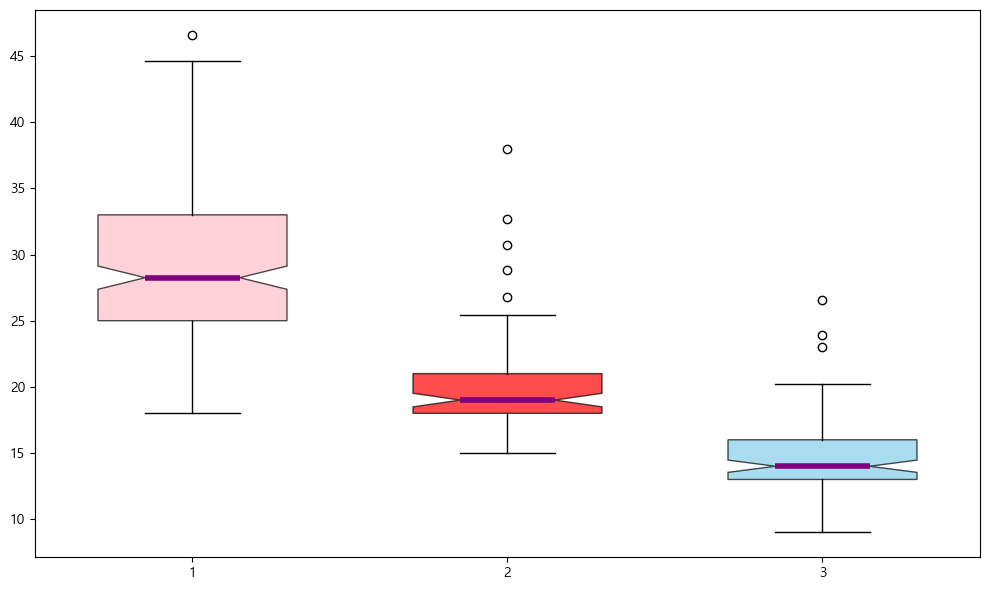

4기통 - 중앙값:26.5 IQR:6.6            이상치개수 : 6
6기통 - 중앙값:26.5 IQR:6.6            이상치개수 : 6
8기통 - 중앙값:26.5 IQR:6.6            이상치개수 : 6


In [ ]:
# boxplot: 이상치, 사분위수
# 실린더 수별로 연비편차가 얼마나 다를까?
fig, ax = plt.subplots(figsize=(10,6))
mpg_clean= mpg[mpg['cylinders'].isin([4,6,8])].copy()

box_data  = [mpg_clean[mpg_clean['cylinders'] == cyl]['mpg'] for cyl in [4,6,8]]
bp = ax.boxplot(box_data,label=['4기통','6기통','8기통'],
                patch_artist=True,notch=True,widths=0.6)

# box 색상
colors = ['pink', 'red', 'skyblue']
for patch, color in zip(bp['boxes'], colors):   # zip 1:1로 묶어줌
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 중앙값선 강조
for median in bp['medians']:
    median.set(color='purple', linewidth=4)

plt.tight_layout()
plt.show()

# 통계요약
for cyl in [4,6,8]:
    mpg_clean[mpg_clean['cylinders'] == 'cyl']['mpg']
    q1, q3 = data.quantile([0.25,0.75])
    iqr = q3-q1
    print(f'{cyl}기통 - 중앙값:{data.median():.1f} IQR:{iqr:.1f} \
           이상치개수 : { len(data[(data > q3+1.5*iqr) | (data < q1 - 1.5*iqr)] ) }' )

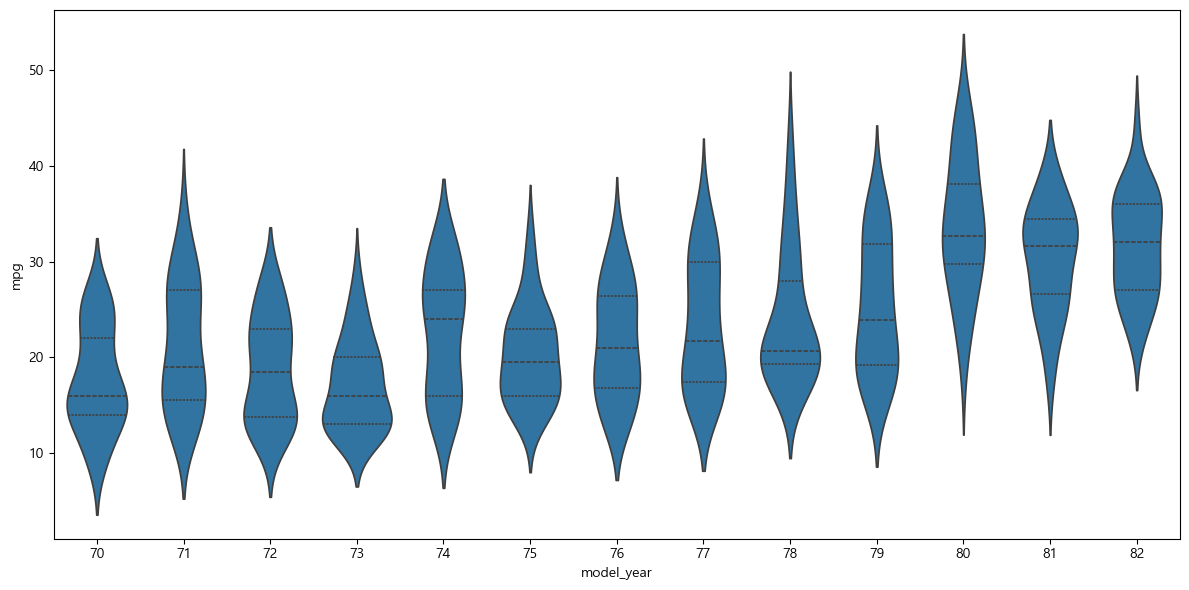

In [33]:
# violineplot 분포형태
# 연식에 따라 연비분포가 어떻게 진화했는지?
fig, ax = plt.subplots(figsize=(12,6))
sns.violinplot(data=mpg, x ='model_year', y='mpg', ax=ax, inner = 'quartitle')
plt.tight_layout()
plt.show()

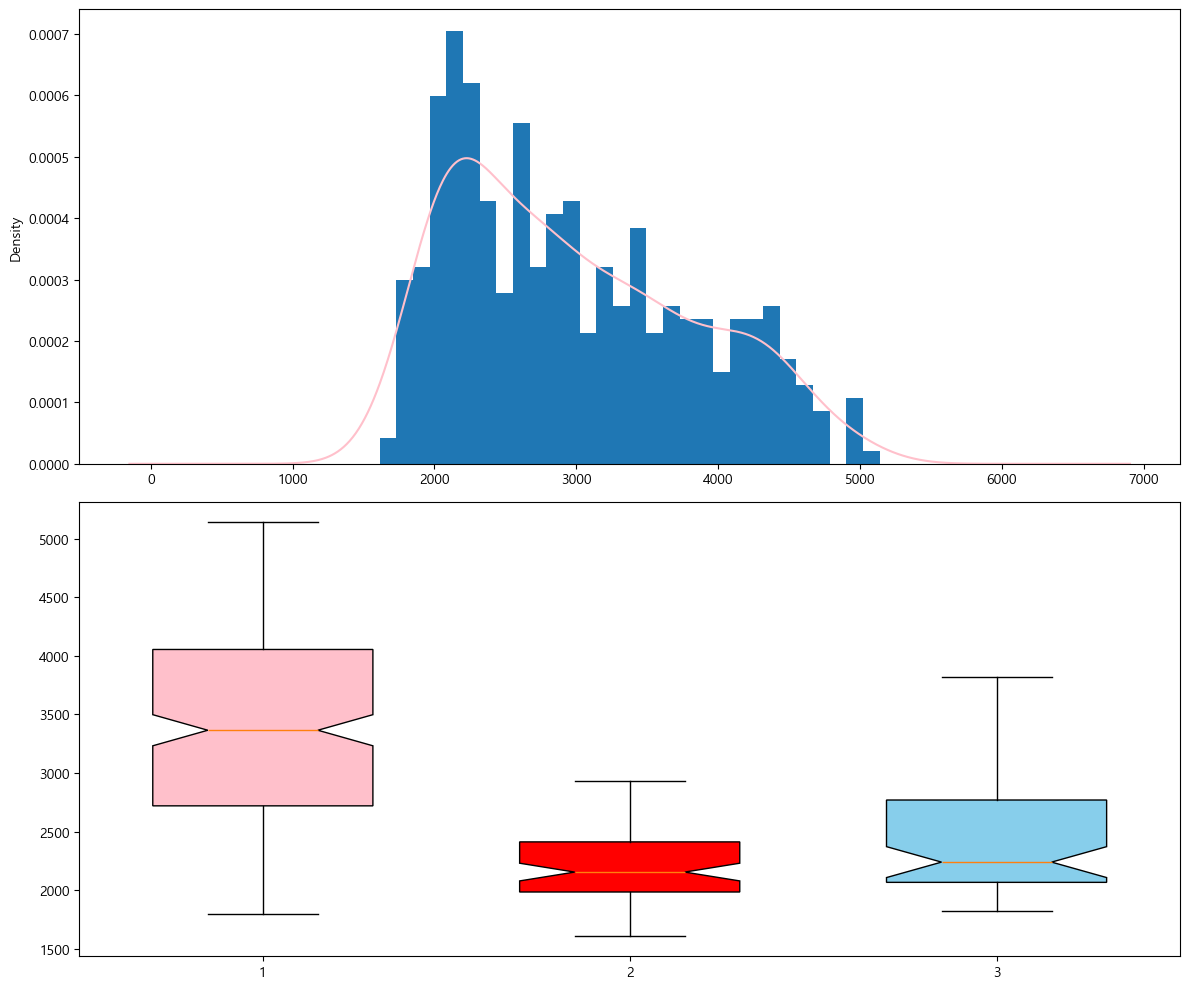

In [40]:
# 히스토그램 + KDE; 밀도 + boxplot
# 차량 무게 분포
fig, ax = plt.subplots(2,1,figsize=(12,10))   # 행,열로 레이아웃 나누기

# 상단 - 히스토그램 + KDE
ax[0].hist(mpg['weight'], bins=30, density=True, label = 'histogram')
mpg['weight'].plot.kde(ax = ax[0], color = 'pink', label = 'kde')

# 하단 - boxplot(제조 국가별)
box_data_weight = [mpg[mpg['origin'] == o]['weight'] for o in ['usa', 'japan', 'europe']]
bp = ax[1].boxplot(box_data_weight, label=['usa', 'japan', 'europe'],
                   patch_artist=True, notch=True,widths=0.6)
for patch, color in zip(bp['boxes'], ['pink', 'red', 'skyblue']):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()
